In [ ]:
Ich möchte Vorhersagen für das Daten-Feld review_score treffen. 
Das Ziel ist es anhand des Textes (review_text) vorhersagen zu können,
ob ein Spieler das Spiel positiv oder negativ bewerten wird.

In [ ]:
!pip install kagglehub pandas matplotlib seaborn scikit-learn

import pandas as pd
import kagglehub
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

path = kagglehub.dataset_download("andrewmvd/steam-reviews")

#Nur erste 100000 Zeilen weil sonst zu viel
csv_dateien = glob.glob(os.path.join(path, "*.csv"))
df = pd.read_csv(csv_dateien[0], nrows=100000)

df.head()

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 2.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.9 MB 2.8 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.9 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.9 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.9 MB 3.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 3.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.5 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 3.5 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.9 MB 3.5 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 3.5 MB/s eta 0:00:01
   ---------------------

100%|██████████| 685M/685M [01:10<00:00, 10.2MB/s] 

Extracting files...


Daten erfolgreich geladen! Hier sind die ersten 5 Zeilen:


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1


In [3]:
print(df.columns.tolist())

['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']


In [4]:
spalten = ['review_score', 'review_votes']

stats = df[spalten].describe()

median = df[spalten].median()

print("Statistische Informationen für deinen Datensatz:")
display(stats)
print("\nMediane der Felder:")
print(median)

Statistische Informationen für deinen Datensatz:


,review_score,review_votes
count,100000.000000,100000.000000
mean,0.728680,0.146030
std,0.684858,0.353138
min,-1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,0.000000
max,1.000000,1.000000



Mediane der Felder:
review_score    1.0
review_votes    0.0
dtype: float64


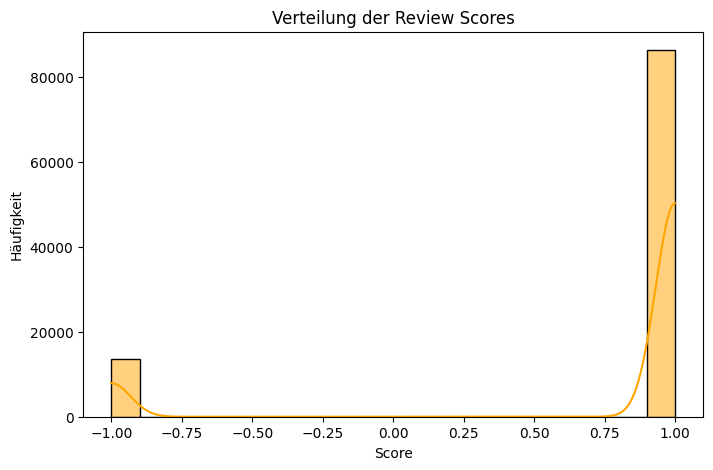

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df['review_score'], bins=20, color='orange', kde=True)

plt.title('Verteilung der Review Scores')
plt.xlabel('Score')
plt.ylabel('Häufigkeit')
plt.show()

In [6]:
In Aufgabe 2.2 sieht man, dass die Spalte review_votes nur die Zahlen 0 und 1 enthält. Auch review_score liegt nur zwischen -1 und 1.
Eine Skalierung benutzt man normalerweise, um riesige Zahlen (wie tausende Spielstunden) auf einen kleinen Bereich von 0 bis 1 zu schrumpfen. 
Da die Zahlen in diesem Datensatz aber sowieso schon winzig sind und sich ohnehin im Bereich um die 0 und 1 bewegen, würde sich durch eine Skalierung
fast nichts verändern. Deshalb finde ich, macht dieser Schritt hier keinen Sinn und ich lassen ihn weg.

Vergleich: Originale Votes vs. Skalierte Votes


,review_votes,review_votes_scaled
0,0,0.0
1,1,1.0
2,0,0.0
3,0,0.0
4,1,1.0
